In [6]:
# Q2: GAN and Autoencoder on Image Data

In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

In [8]:
#2. Build and train a GAN with a Generator that takes random noise as input and a
#Discriminator that classifies images as real or fake, training both adversarially on
#the downloaded animal images for at least 10 epochs using BCELoss and the Adam
#optimizer.

# 1. Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu" # checks if GPU exists & to use NVIDA GPU if not use cpu
)

print("Using device:", device)

# 2. transform
transform = transforms.Compose([

    transforms.Resize((64, 64)), # make all the images the same zie

    transforms.ToTensor(), # handles PIL → tensor automatically

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# load train amd val datasets
train_dataset_path = "GANandAImages/train"
val_dataset_path = "GANandAImages/val"

train_dataset = datasets.ImageFolder(
    root=train_dataset_path,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=val_dataset_path,
    transform=transform
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

Using device: cpu


In [9]:
# 3. Build and train a separate Autoencoder with an Encoder that compresses each image
#into a 16-dimensional latent vector and a Decoder that reconstructs the original image,
# minimizing MSELoss across the training set.

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder compresses image into a smaller representation
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64 * 3, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 16)
        )

        # Decoder reconstructs image from compressed representation
        self.decoder = nn.Sequential(
            nn.Linear(16, 256),  # <--- CHANGE THIS from 100 (or whatever it was) to 16
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 64 * 64 * 3),
            nn.Tanh()
        )

    def forward(self, x):

        encoded = self.encoder(x)

        decoded = self.decoder(encoded)

        decoded = decoded.view( x.size(0), 3, 64, 64)

        return decoded

# Initialize Autoencoder
autoencoder = Autoencoder().to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# Training loop
epochs = 10

for epoch in range(epochs):
    autoencoder.train()
    total_loss = 0.0
    
    for images, _ in train_loader:
        images = images.to(device)
        
        # Autoencoder target is the original image itself
        reconstructed = autoencoder(images)
        # Compare reconstruction with original input
        loss = criterion(reconstructed, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f"Epoch [{epoch + 1}/{epochs}],"
            f"Loss: {total_loss / len(train_loader):.4f}"
    )

Epoch [1/10],Loss: 0.1091
Epoch [2/10],Loss: 0.0843
Epoch [3/10],Loss: 0.0799
Epoch [4/10],Loss: 0.0782
Epoch [5/10],Loss: 0.0772
Epoch [6/10],Loss: 0.0761
Epoch [7/10],Loss: 0.0753
Epoch [8/10],Loss: 0.0743
Epoch [9/10],Loss: 0.0736
Epoch [10/10],Loss: 0.0729


Final Reconstruction Loss: 0.07810600101947784


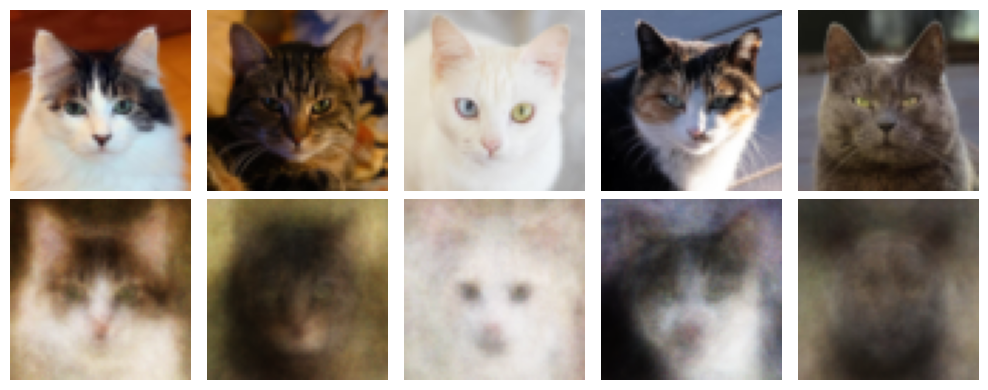

In [10]:
#4. Visualize the results of both models - for the GAN, show 5 generated fake images after
#training; for the Autoencoder, show 5 original images alongside their reconstructions
#and report the final reconstruction loss.

# visuaize 
autoencoder.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    reconstructed = autoencoder(images)

test_loss = criterion(reconstructed, images).item()
print("Final Reconstruction Loss:", test_loss)   

# Show first 5 images
plt.figure(figsize=(10,4))

for i in range(5):

    # ORIGINAL
    plt.subplot(2,5,i+1)
    img = denorm(images[i].cpu())
    plt.imshow(img.permute(1,2,0))
    plt.axis("off")

    # RECONSTRUCTED
    plt.subplot(2,5,i+6)
    recon = denorm(reconstructed[i].cpu())
    plt.imshow(recon.permute(1,2,0))
    plt.axis("off")

plt.tight_layout()
plt.show()

Epoch 1, D Loss=0.9009, G Loss=0.9139
Epoch 2, D Loss=0.9196, G Loss=0.9537
Epoch 3, D Loss=0.4981, G Loss=2.4334
Epoch 4, D Loss=0.6822, G Loss=1.8702
Epoch 5, D Loss=0.4756, G Loss=3.7755
Epoch 6, D Loss=0.6039, G Loss=1.9361
Epoch 7, D Loss=0.5136, G Loss=2.5667
Epoch 8, D Loss=0.4611, G Loss=2.6160
Epoch 9, D Loss=0.4507, G Loss=3.6522
Epoch 10, D Loss=0.4136, G Loss=3.4032


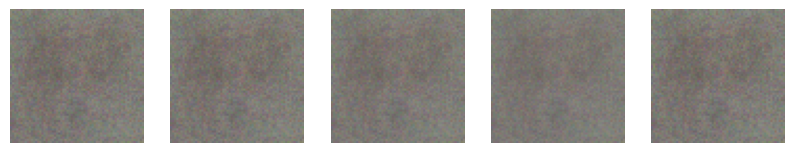

Final Reconstruction Loss: 0.0790798735494415


In [11]:
# GAN

# latent size
latent_dim = 100

# generator 
class Generator(nn.Module):

    def __init__(self):

        super().__init__()
        
        self.model = nn.Sequential(

            nn.Linear(latent_dim, 256),

            nn.ReLU(),

            nn.Linear(256, 512),

            nn.ReLU(),

            nn.Linear(512, 1024),

            nn.ReLU(),

            nn.Linear(1024, 64*64*3),

            nn.Tanh()
        )

    def forward(self, z):

        img = self.model(z)

        return img.view(z.size(0), 3, 64, 64)

# discriminator
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*64*3, 512),

            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),

            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),

            nn.Sigmoid()
        )

    def forward(self, img):

        return self.model(img)

# initiallize GAN
G = Generator().to(device)

D = Discriminator().to(device)

# Gan loss and optimizers
criterion_gan = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0001)

# train GAN
epochs = 10

for epoch in range(epochs):

    for images, _ in train_loader:

        real_imgs = images.to(device)

        batch_size = real_imgs.size(0)

        # Labels

        real_labels = (torch.ones(batch_size, 1) * 0.9).to(device) # Label Smoothing
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ==========================
        # TRAIN DISCRIMINATOR
        # ==========================

        opt_D.zero_grad()

        # Real images
        real_output = D(real_imgs)

        real_loss = criterion_gan(
            real_output,
            real_labels
        )

        # Fake images
        z = torch.randn(
            batch_size,
            latent_dim
        ).to(device)

        fake_imgs = G(z)


        fake_output = D(fake_imgs.detach())

        fake_loss = criterion_gan(
            fake_output,
            fake_labels
        )

        # Total discriminator loss
        d_loss = real_loss + fake_loss

        d_loss.backward()

        opt_D.step()

        # ==========================
        # TRAIN GENERATOR
        # ==========================

        opt_G.zero_grad()

        z = torch.randn(
            batch_size,
            latent_dim
        ).to(device)

        fake_imgs = G(z)

        generator_output = D(fake_imgs)

        g_loss = criterion_gan(
            generator_output,
            real_labels
        )

        g_loss.backward()

        opt_G.step()

    print(
        f"Epoch {epoch+1}, "
        f"D Loss={d_loss.item():.4f}, "
        f"G Loss={g_loss.item():.4f}"
    )

# generate the fake images
G.eval()

with torch.no_grad():
    z = torch.randn(5, latent_dim).to(device)
    fake_images = G(z)

plt.figure(figsize=(10,2))

for i in range(5):

    img = denorm(fake_images[i].cpu())

    plt.subplot(1,5,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.axis("off")

plt.show()

# final reconstruction loss 
print("Final Reconstruction Loss:", final_recon_loss)

In [12]:
#5. Compare and discuss the two approaches by explaining how the adversarial loss in
#GANs differs from the reconstruction loss in Autoencoders, what each model’s output
#reveals about what was learned, and which approach produced better visual results
#and why.


In [ ]:
# The GAN and Autoencoder learned image representations in different ways.

# The GAN used adversarial learning where the Generator tried to create realistic fake animal faces while the Discriminator attempted to distinguish real images from fake images. 
# The adversarial loss encouraged the Generator to produce visually realistic images.

# The Autoencoder used reconstruction learning where the Encoder compressed each image into a 16-dimensional latent vector 
# and the Decoder reconstructed the original image. 
# The reconstruction loss (MSELoss) minimized the pixel-wise difference between the original and reconstructed images.

# The GAN outputs demonstrated the model’s ability to generate new synthetic animal faces that did not exist in the dataset.
# The Autoencoder outputs demonstrated the model’s ability to compress and reconstruct images while preserving important visual features.

# The GAN generally produced more visually interesting and realistic outputs because adversarial training focuses on realism. 
# However, GAN training is more unstable and difficult. 
#The Autoencoder produced blurrier reconstructions because MSELoss averages pixel errors and does not explicitly encourage sharp image generation.